<h1 align="center">Machine Learning for Bioinformatics</h1>
<h3 align="center">Freie Universität Berlin</h3>
<h5 align="center">Exercise Notebook - Artificial Neural Network Architectures</h5>
<hr style="border:2px solid gray">

### Import python packages
---

In [1]:
!pip install ipywidgets

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/914.9 kB ? eta -:--:--
   ---------------------------------------- 914.9/914.9 kB 6.4 MB/s  0:00:00
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ---------------------------------------- 2.2/2.2 MB 11.5 MB/s  0:00:00

   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   ---------------------------------------- 3/3 [ipywidgets]



In [2]:
import numpy as np
import matplotlib.pyplot as plt
import abc
import gzip
import pickle
from collections import Counter

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, roc_auc_score

import torch
from torch.utils.data import Dataset, DataLoader

from accelerate import Accelerator

---
# Assignment 1: Vanishing gradient
---

We generate some simple random data with $n = 1000$ samples and $p = 100$ features:

In [32]:
n = 1000
p = 100
X = np.random.rand(n, p)
y = np.random.randint(2, size=n).reshape(-1,1)

In [36]:
def eval_gradient(model, X, y, n_hidden = 100, n_repeat = 10):
    result = np.array([0.0] * n_hidden)
    for i in range(n_hidden):
        model.set_num_hidden_layers(i)
        for _ in range(n_repeat):
            result[i] += model.gradient_length(X, y, torch.nn.BCELoss())
    result /= n_repeat

    print(result[:20])

    plt.plot(result)
    plt.xlabel('number of hidden layers')
    plt.ylabel('gradient magnitude')
    plt.show()

In [37]:
class GradientNetwork(abc.ABC, torch.nn.Module):
    def __init__(self, size, n=1):
        __metaclass__ = abc.ABCMeta
        super(GradientNetwork, self).__init__()
        self.linear1 = torch.nn.Linear(size, size)
        self.linear2 = torch.nn.Linear(size, size)
        self.linear3 = torch.nn.Linear(size, 1)
        self.activation = torch.nn.Sigmoid()
        self.n = n

    @abc.abstractmethod
    def forward(self, x):
        return

    def gradient_length(self, X, y, loss_fn):
        self.zero_grad()
        X = torch.tensor(X, dtype=torch.float32)
        y = torch.tensor(y, dtype=torch.float32)
        y_hat = self(X)
        loss = loss_fn(y_hat, y)
        loss.backward()
        return torch.norm(self.linear1.weight.grad).item()

    def set_num_hidden_layers(self, n):
        self.n = n

---
## 1.1 Vanishing gradient network
---

In [38]:
class VanishingGradientNetwork(GradientNetwork):
    def __init__(self, size, n=1):
        super(VanishingGradientNetwork, self).__init__(size, n=n)

    def forward(self, x):
        x = self.linear1(x)
        x = self.activation(x)
        for _ in range(self.n):
            x = self.linear2(x)
            x = self.activation(x)
        x = self.linear3(x)
        x = self.activation(x)
        return x

[1.52352871e-02 8.64299713e-04 9.64411520e-05 1.48688041e-05
 2.05465608e-06 3.00037271e-07 4.28519940e-08 5.81730086e-09
 7.80412845e-10 1.06519037e-10 1.50962264e-11 1.78134059e-12
 2.38688192e-13 3.42124298e-14 4.72802102e-15 7.05292148e-16
 8.83309582e-17 1.31000081e-17 1.83627954e-18 2.57385907e-19]


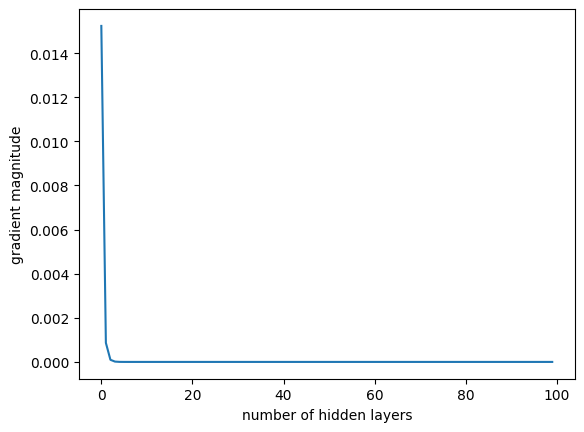

In [39]:
eval_gradient(VanishingGradientNetwork(p), X, y)

---
## 1.2 Network with skip connections
---

In [40]:
class SkipGradientNetwork(GradientNetwork):
    def __init__(self, size, n=1):
        super(SkipGradientNetwork, self).__init__(size, n=n)

    def forward(self, x):
        x = self.linear1(x)
        x = self.activation(x)
        for _ in range(self.n):
            y = self.linear2(x)
            y = self.activation(y)
            x = x + y
        x = self.linear3(x)
        x = self.activation(x)
        return x

[0.05957097 0.13854946 0.20970325 0.27039075 0.32093501 0.3637239
 0.4017382  0.43761194 0.47331658 0.51015353 0.54885411 0.58971685
 0.63275784 0.67784244 0.7247808  0.77338511 0.8234942  0.87498665
 0.92778438 0.98185349]


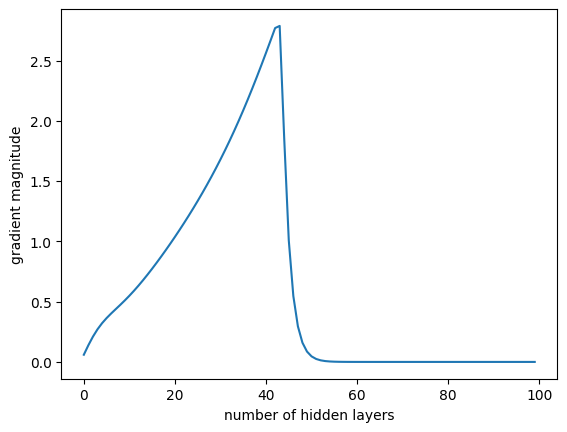

In [41]:
eval_gradient(SkipGradientNetwork(p), X, y)

---
## 1.3 Network with batch norm
---

In [42]:
class NormGradientNetwork(GradientNetwork):
    def __init__(self, size, n=1):
        super(NormGradientNetwork, self).__init__(size, n=n)
        # Define a 1D batch normalization here!
        self.bn = torch.nn.BatchNorm1d(num_features=size)


    def forward(self, x):
        x = self.linear1(x)
        x = self.activation(x)
        for _ in range(self.n):
            x = self.linear2(x)
            
            # Apply the batch normalization
            x = self.bn(x)

            x = self.activation(x)
        x = self.linear3(x)
        x = self.activation(x)
        return x

[0.10081203 0.03249066 0.03488797 0.03534437 0.03759424 0.04411822
 0.04597434 0.04742917 0.04324773 0.04210236 0.04521035 0.04615488
 0.04819506 0.0528522  0.05263868 0.05624021 0.05747305 0.05592184
 0.05805721 0.05552984]


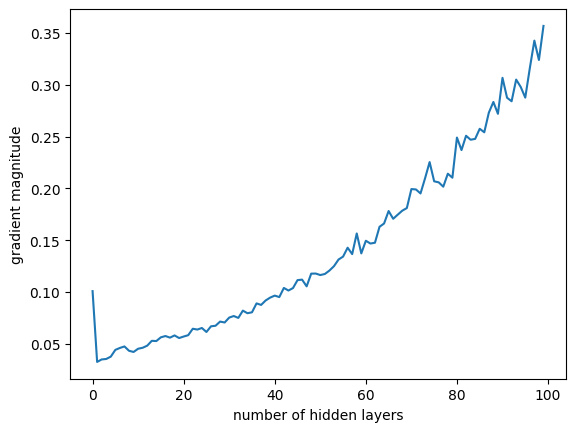

In [43]:
eval_gradient(NormGradientNetwork(p), X, y)

---
## 1.4 ReLU activation
---

In [44]:
class ReluGradientNetwork(GradientNetwork):
    def __init__(self, size, n=1):
        super(ReluGradientNetwork, self).__init__(size, n=n)
        # Define a ReLU activation
        self.activation = torch.nn.ReLU()

    def forward(self, x):
        x = self.linear1(x)
        x = self.activation(x)
        for _ in range(self.n):
            x = self.linear2(x)
            # Apply the ReLU activation
            x = self.activation(x)

        x = self.linear3(x)
        x = self.activation(x)
        return x

[  9.22486019  17.28117943 102.45355988   0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.        ]


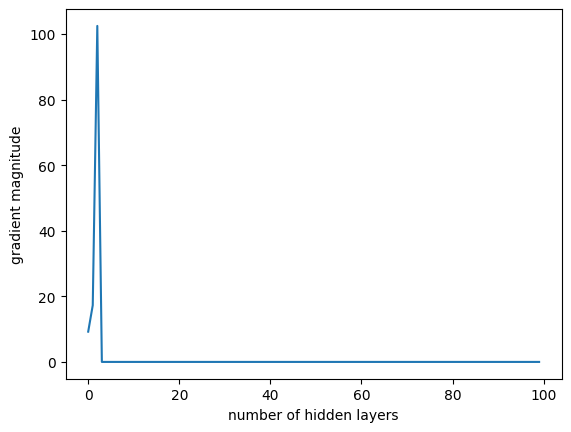

In [45]:
eval_gradient(ReluGradientNetwork(p), X, y)

In [46]:
class ELUGradientNetwork(GradientNetwork):
    def __init__(self, size, n=1):
        super(ELUGradientNetwork, self).__init__(size, n=n)
        self.activation = torch.nn.ELU()
        self.sigmoid = torch.nn.Sigmoid()

    def forward(self, x):
        x = self.linear1(x)
        x = self.activation(x)
        for _ in range(self.n):
            x = self.linear2(x)
            x = self.activation(x)

        x = self.linear3(x)
        x = self.sigmoid(x)
        return x

[1.11738317e-01 4.75714393e-02 2.25497000e-02 1.43453125e-02
 7.33412197e-03 4.63392586e-03 2.58119265e-03 1.74839213e-03
 1.02754333e-03 6.25844172e-04 3.44273809e-04 2.26348086e-04
 1.26066603e-04 7.35980429e-05 4.29717402e-05 2.10846829e-05
 1.16848005e-05 7.18516367e-06 4.48298442e-06 2.39011251e-06]


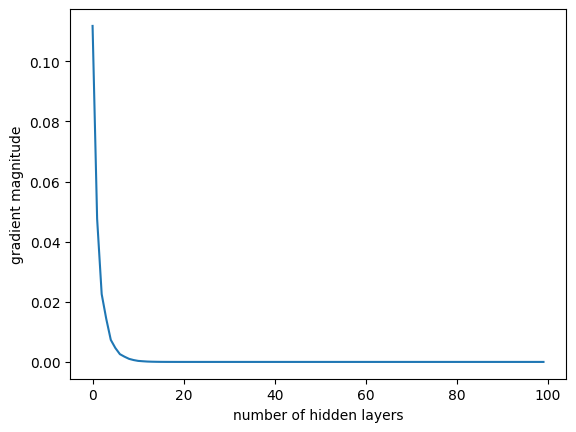

In [47]:
eval_gradient(ELUGradientNetwork(p), X, y)

---
# Assignment 2: Prediction of active enhancers with CNNs
---

---
## 2.1 Torch dataset
---

In [18]:
class EnhancerData(Dataset):
    def __init__(self, path_to_data = 'exercise-data/enhancer_liver_onehot_balanced.pkl.gz'):
        
        ## import the dataset 
        with gzip.open(path_to_data, 'rb') as f:
            records, labels = pickle.load(f)
        # Convert records in one-hot format to a numeric matrix, which can be used as input to our model
        records = np.array(records, dtype=np.float32)
        # we will use the 1D convolution which takes input in format(data size, channels, seq length) - transpose
        self.X = np.transpose(records, (0, 2, 1))
        self.X = torch.tensor(self.X)
        # Create a vector on numeric labels
        self.y = labels.astype('float32').reshape(-1,1)
        self.y = torch.tensor(self.y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return {'X': self.X[idx], 'y': self.y[idx]}

In [19]:
def get_seq(seq):
   labels_again = np.argmax(seq, axis =0)
   labels_again = ['A' if i ==0 else ('C' if i==1 else('G' if i ==2 else('T')))for i in labels_again]
   return ''.join(labels_again)

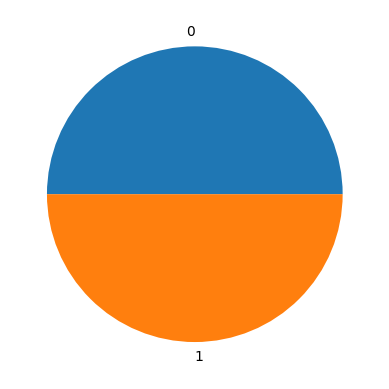

In [20]:
enhancer_data = EnhancerData()

plt.pie(Counter(enhancer_data.y[:,0].cpu().numpy()).values(), labels = [0, 1])
plt.show()

---
## 2.2 Accelerate data
---

In [21]:
class EnhancerDataModule:
    def __init__(self, n_splits = 5, val_size = 0.2, batch_size = 32, num_workers = 0):
        self.val_size    = val_size
        self.batch_size  = batch_size
        self.num_workers = num_workers
        self.data        = EnhancerData()
        self.splits      = list(StratifiedKFold(n_splits).split(self.data.X, self.data.y))
        self.n_splits    = n_splits

    def setup_fold(self, k):
        self.k = k

    def setup(self):
        train_index, test_index = self.splits[self.k]
        # Split the data into training and testing
        data_size_val   = int(len(train_index)*self.val_size)
        data_size_train = len(train_index) - data_size_val
        data_train      = torch.utils.data.Subset(self.data, train_index)
        data_test       = torch.utils.data.Subset(self.data, test_index )
        data_train, data_val = torch.utils.data.random_split(data_train, [data_size_train, data_size_val])
        self.data_train = data_train
        self.data_test  = data_test
        self.data_val   = data_val

    def train_dataloader(self):
        return DataLoader(self.data_train, batch_size=self.batch_size, num_workers=self.num_workers)

    def val_dataloader(self):
        return DataLoader(self.data_val, batch_size=self.batch_size, num_workers=self.num_workers)

    def test_dataloader(self):
        return DataLoader(self.data_test, batch_size=self.batch_size, num_workers=self.num_workers)


---
## 2.3 Accelerate utilities
---

In [22]:
import warnings
warnings.filterwarnings("ignore", ".*does not have many workers.*")


In [23]:
def mean_loss(losses):
    if len(losses) == 0:
        return float('nan')
    return torch.mean(torch.tensor(losses, dtype=torch.float)).item()


In [24]:
def move_batch_to_device(batch, device):
    return {key: value.to(device) for key, value in batch.items()}


def clone_state_dict(accelerator, model):
    model = accelerator.unwrap_model(model)
    return {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}


---
## 1.3 Torch Network Module
---

With Accelerate the implementation of the model stays within a Torch module. We want to implement a CNN model with two convolutional layers. Complete the implementation with the following layers (you must keep the exact sequential order):

* 1D convolutional layer with 4 input and 100 output channels. This means that we are using 100 kernels in out convolution. Set the stride to 1 and use a padding of 0
* 1D batch normalization layer
* Leaky ReLU activation
* Max pooling layer with a kernel size of 2, stride set to None and a padding of 0
* 1D convolutional layer with 100 input and 10 output channels. The remaining parameters are identical to the first convolutional layer
* 1D batch normalization layer
* Leaky ReLU activation

The output of the convolutional layers is first averaged and then given as input to a dense neural network for computing the final prediction.

In [25]:
class DetectActiveEnhancersNetwork(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.convolutional_sequence = torch.nn.Sequential(
            
            # Complete the implementation of the convolutional network
            torch.nn.Conv1d(in_channels=4, out_channels=100, kernel_size=3, stride=1, padding=0),
            torch.nn.BatchNorm1d(num_features=100),
            torch.nn.LeakyReLU(),
            torch.nn.MaxPool1d(kernel_size=2, stride=None, padding=0),
            torch.nn.Conv1d(in_channels=100, out_channels=10, kernel_size=3, stride=1, padding=0),
            torch.nn.BatchNorm1d(num_features=10),
            torch.nn.LeakyReLU()
        )
        self.linear_sequence = torch.nn.Sequential(   
            torch.nn.Linear(10,1),
            torch.nn.Sigmoid()
        )

    def forward(self, x):
        x = self.convolutional_sequence(x)
        # Average output of convolutional layers
        x = x.mean(2)
        x = self.linear_sequence(x)
        return x

---
## 1.4 Accelerate training functions
---

In [26]:
def train_epoch(model, train_loader, optimizer, loss_fn, accelerator):
    model.train()
    losses = []
    for batch in train_loader:
        batch = move_batch_to_device(batch, accelerator.device)
        optimizer.zero_grad()
        y_hat = model(batch['X'])
        loss  = loss_fn(y_hat, batch['y'])
        accelerator.backward(loss)
        optimizer.step()
        loss_value = accelerator.gather_for_metrics(loss.detach().float().reshape(1)).mean().cpu().item()
        losses.append(loss_value)
    return mean_loss(losses)


@torch.no_grad()
def evaluate_model(model, data_loader, loss_fn, accelerator, collect_predictions = False):
    model.eval()
    losses = []
    y_batches = []
    y_hat_batches = []
    for batch in data_loader:
        batch = move_batch_to_device(batch, accelerator.device)
        y_hat = model(batch['X'])
        loss  = loss_fn(y_hat, batch['y'])
        loss_value = accelerator.gather_for_metrics(loss.detach().float().reshape(1)).mean().cpu().item()
        losses.append(loss_value)
        if collect_predictions:
            y_batches.append(accelerator.gather_for_metrics(batch['y'].detach()).cpu())
            y_hat_batches.append(accelerator.gather_for_metrics(y_hat.detach()).cpu())
    if collect_predictions:
        return mean_loss(losses), torch.cat(y_batches), torch.cat(y_hat_batches)
    return mean_loss(losses)


def fit_model(model, data, max_epochs = 1000, lr = 0.001, patience = 10):
    data.setup()
    accelerator = Accelerator()
    loss_fn     = torch.nn.BCELoss()
    optimizer   = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler   = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, mode='min')

    train_loader = data.train_dataloader()
    val_loader   = data.val_dataloader()
    test_loader  = data.test_dataloader()
    model, optimizer, train_loader, val_loader, test_loader, scheduler = accelerator.prepare(
        model, optimizer, train_loader, val_loader, test_loader, scheduler)

    train_error = []
    val_error = []
    best_val_loss = float('inf')
    best_state = None
    epochs_without_improvement = 0

    for _ in range(max_epochs):
        train_loss = train_epoch(model, train_loader, optimizer, loss_fn, accelerator)
        val_loss   = evaluate_model(model, val_loader, loss_fn, accelerator)
        scheduler.step(val_loss)
        train_error.append(train_loss)
        val_error.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = clone_state_dict(accelerator, model)
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            break

    unwrapped_model = accelerator.unwrap_model(model)
    if best_state is not None:
        unwrapped_model.load_state_dict(best_state)

    _, test_y, test_y_hat = evaluate_model(model, test_loader, loss_fn, accelerator, collect_predictions=True)
    stats = {
        'best_val_loss' : best_val_loss,
        'train_error'   : train_error,
        'val_error'     : val_error }

    return unwrapped_model, stats, test_y, test_y_hat


---
## 1.5 Main cross-validation loop
---

In [27]:
data = EnhancerDataModule(n_splits = 5)

y_hat = np.array([])
y     = np.array([])

for fold in range(data.n_splits):

    data.setup_fold(fold)

    model = DetectActiveEnhancersNetwork()

    # Accelerate automatically uses a GPU if one is available.
    model, stats, test_y, test_y_hat = fit_model(model, data, max_epochs=1000, lr=0.001, patience=10)

    # Evaluate model
    y_hat = np.append(y_hat, test_y_hat.numpy())
    y     = np.append(y    , test_y.numpy())


Text(0.5, 1.0, '5-fold CV ROC-Curve (AUC: 0.77)')

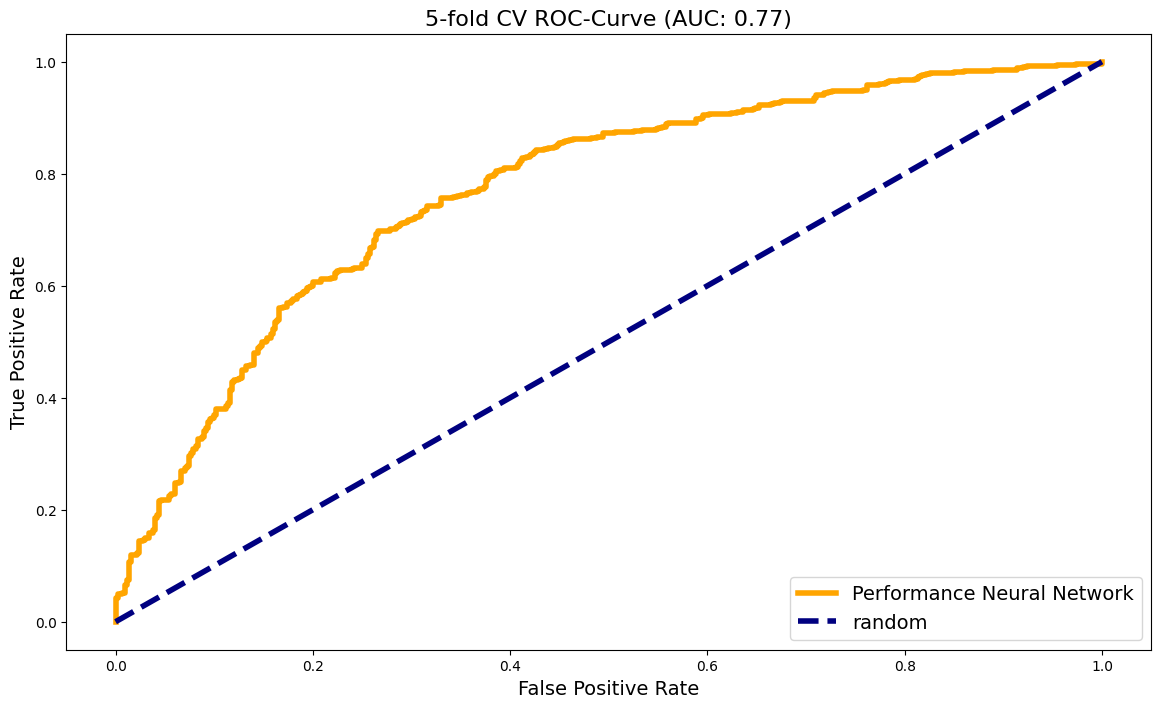

In [28]:
roc_auc = roc_auc_score(y_score=y_hat, y_true=y)
tpr, fpr, _ = roc_curve(y_score=y_hat, y_true=y)

fig = plt.figure(figsize=(14, 8))
plt.plot(tpr, fpr, label='Performance Neural Network', lw=4, color='orange')
plt.xlabel('False Positive Rate', fontsize = 14)
plt.ylabel('True Positive Rate', fontsize = 14)
plt.plot([0, 1], [0, 1], color='navy', lw=4, linestyle='--', label='random')
plt.legend(loc='lower right', fontsize = 14)
plt.title("5-fold CV ROC-Curve (AUC: {:0.2f})".format(roc_auc), fontsize = 16)

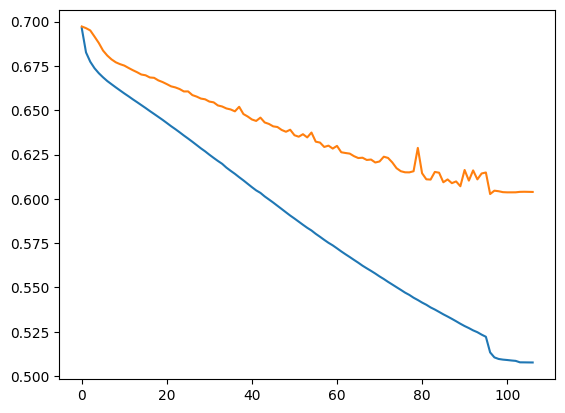

In [29]:
# Plot train and validation error of the last CV fold
plt.plot(stats['train_error'])
plt.plot(stats['val_error'])
plt.show()